In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

projection_method = "PCA"

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["transformer"])
df = qm9.load()
X = np.array(df["selfies_transformer"].to_list())

2026-05-08 10:18:56.446 | INFO     | src.datasets:load:867 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-08 10:18:56.832 | INFO     | src.datasets:_sample_qm9_df:1073 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-05-08 10:18:56.833 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-05-08 10:18:56.834 | INFO     | src.features:compute_selfies_transformer:242 - Computing SELFormer Embeddings using HUBioDataLab/SELFormer...
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/tokenizer_config.json "HTTP/1.

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/main "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/discussions?p=0 "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"
2026-05-08 10:19:20.680 | INFO     | src.datasets:_add_requested_descriptors:227 - Added descriptor column(s): ['selfies_transformer']


In [4]:
len(df['selfies_transformer'].to_list()[0])

768

In [5]:
molecules = qm9.get_molecules()

2026-05-07 20:36:16.405 | SUCCESS  | src.datasets:get_molecules:1689 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).


In [6]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [4]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="transformer",
    dist_type="euclidean",
    force_calculate=True,
    pca_components=6,
)

2026-05-08 10:19:21.047 | INFO     | src.datasets:get_distance_matrix:1479 - Applying PCA to reduce 'selfies_transformer' to 6 dimensions.
2026-05-08 10:19:21.087 | INFO     | src.datasets:get_distance_matrix:1483 - PCA kept 56.62% of the variance for 'selfies_transformer'.
2026-05-08 10:19:21.088 | INFO     | src.datasets:get_distance_matrix:1485 - PCA reduced 'selfies_transformer' dimensions from 768 to 6
2026-05-08 10:19:21.101 | INFO     | src.datasets:get_distance_matrix:1500 - Calculating distance matrix for selfies_transformer using euclidean distance.
2026-05-08 10:19:21.293 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/QM9/dist_selfies_transformer_euclidean_pca6.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:05<00:00,  1.73it/s]


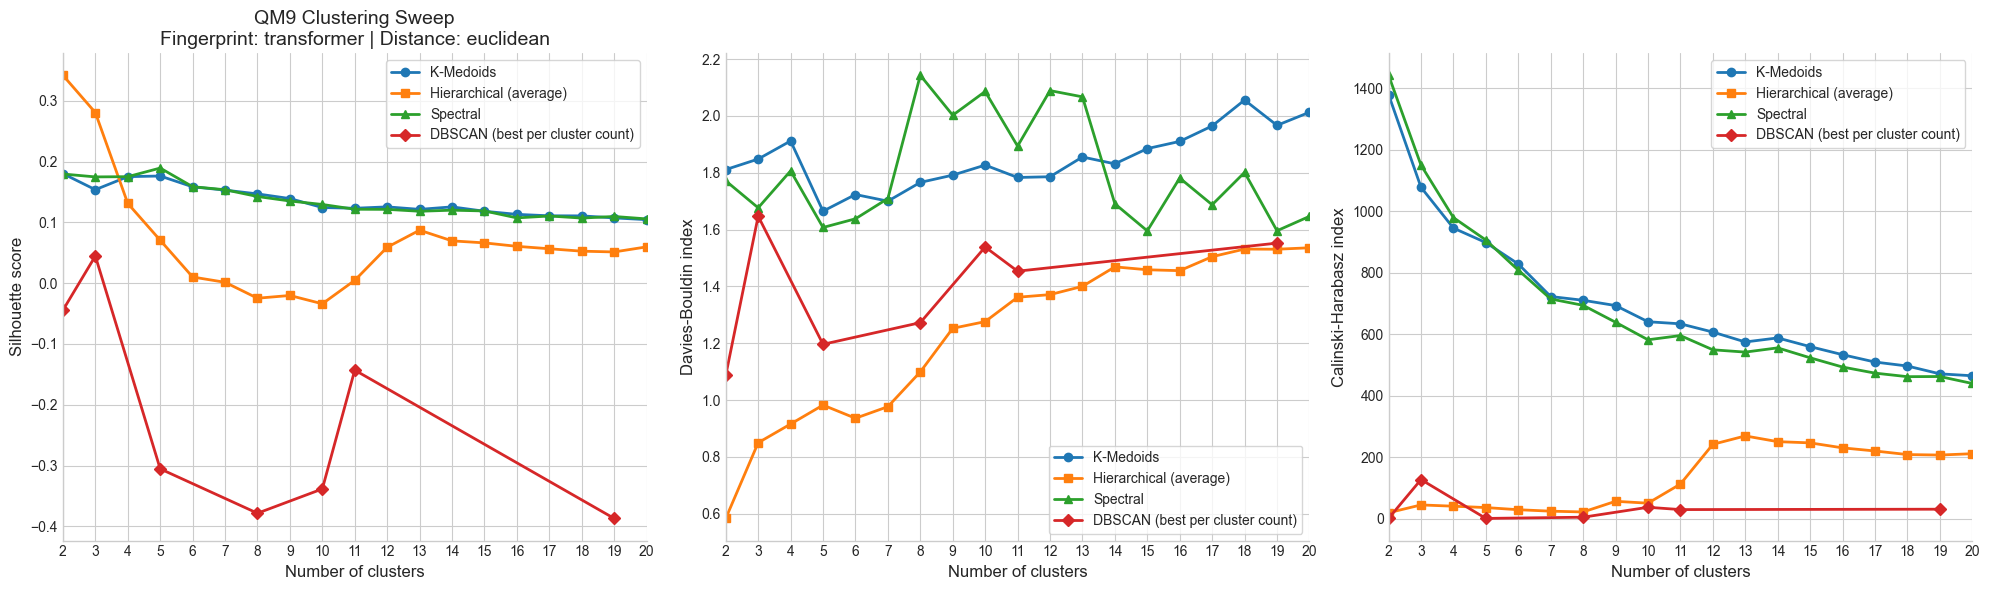

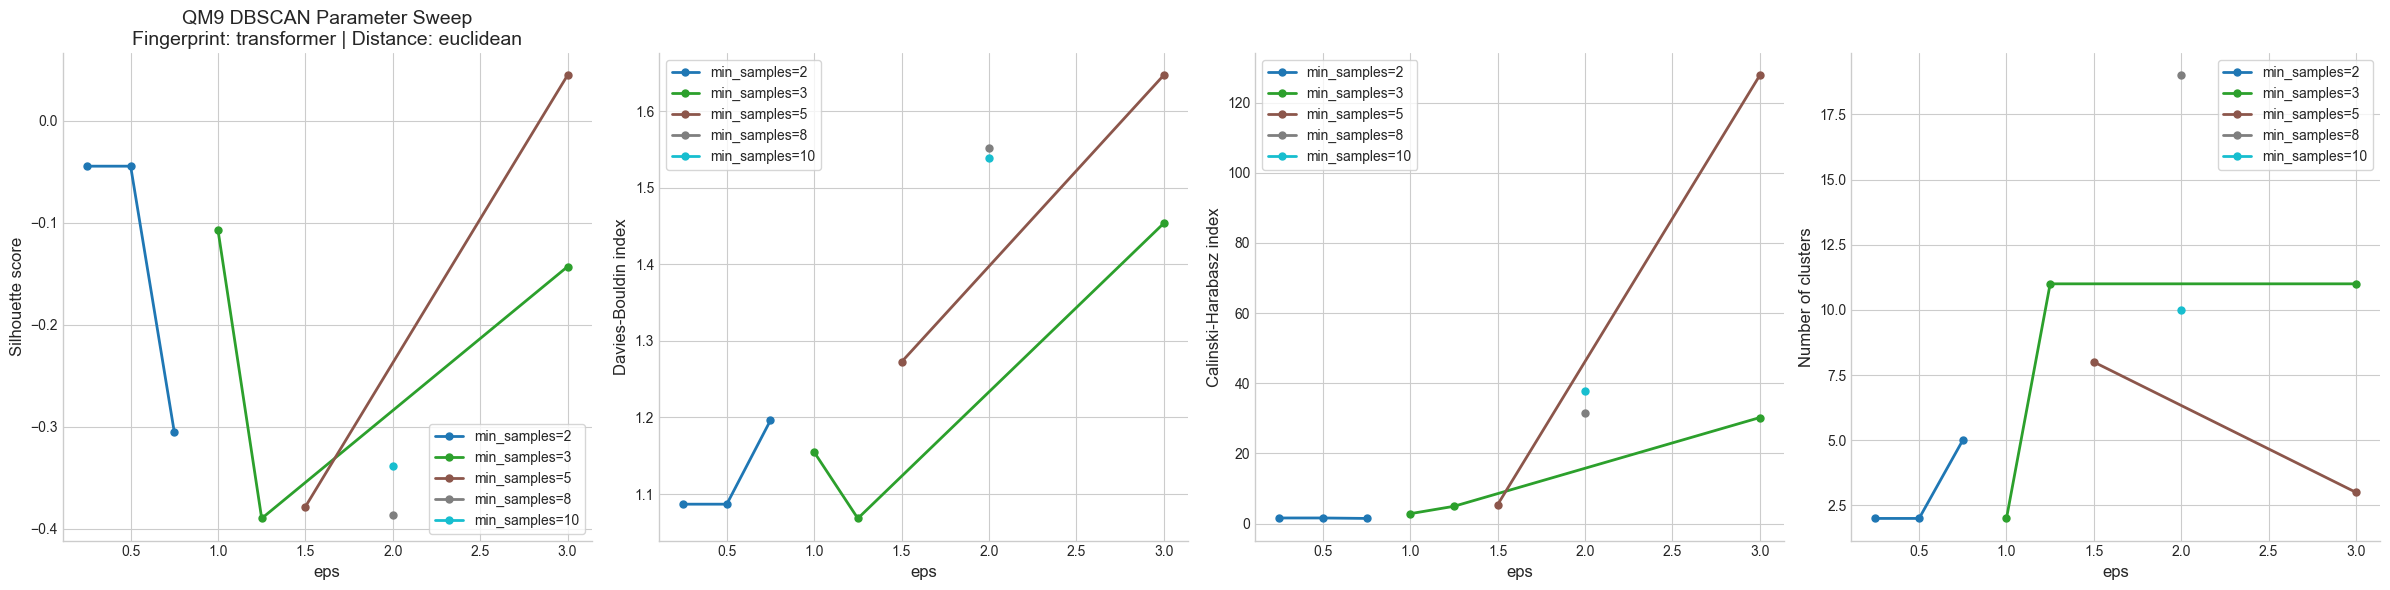

2026-05-07 20:37:14.119 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1060 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/transformer/clustering_sweep_2_to_20_clusters.png
2026-05-07 20:37:14.119 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1062 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/transformer/dbscan_parameter_sweep.png
2026-05-07 20:37:14.120 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1063 - Saved clustering sweep results to figures/qm9/clustering/euclidean/transformer/clustering_sweep_2_to_20_clusters.json


In [8]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    dataset_name="qm9",
)

In [9]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(4856), np.int64(4857)), (np.int64(848), np.int64(849)), (np.int64(4204), np.int64(4520)), (np.int64(2132), np.int64(2133)), (np.int64(2352), np.int64(2353)), (np.int64(2339), np.int64(2340)), (np.int64(3320), np.int64(3321)), (np.int64(1483), np.int64(3016)), (np.int64(2588), np.int64(3514)), (np.int64(3190), np.int64(3191))]


In [10]:
print(mols[0])

(Atoms(symbols='NC2OCN2COH5', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='NC2ON2C2OH5', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [11]:
plot_molecules_with_py3dmol(mols[1])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

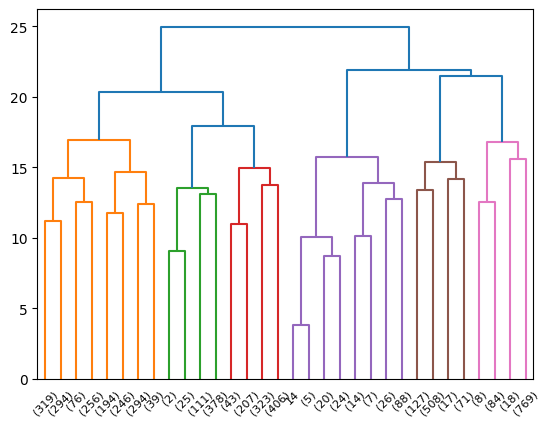

In [5]:
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=4                 
)

In [14]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=2, linkage='average')
labels_hier = model_hier.fit_predict(dist_matrix)
print(np.unique(labels_hier, return_counts=True))
df = df.with_columns(labels_hier=labels_hier)

(array([0, 1]), array([4989,   11]))


In [7]:
create_chemiscope_viewer(df, X, labels_hier, 'PCA')

2026-05-08 10:19:42.860 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-08 10:19:42.860 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-08 10:20:34.931 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-08 10:20:34.939 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-08 10:20:35.177 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-08 10:20:35.551 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

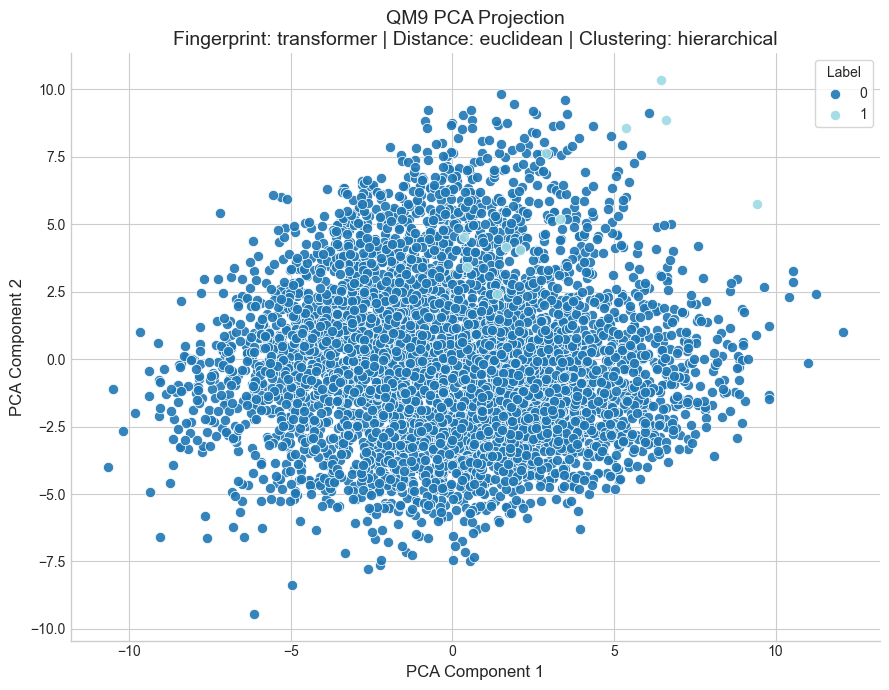

2026-05-08 10:23:13.705 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_hierarchical_projection.png


In [15]:
_=plot_distance_matrix_projection(
    dist_matrix=X,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [16]:
average_numeric_by_cluster(df, "labels_hier")

shape: (3, 71)
┌─────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬─────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2299,0.73985,0.0,122.518921,-0.077425,34.615485,0.863423,12.849287,8.758591,1.682906,0.050892,0.013919,2.330579,18.766855,2.062533,2.484124,0.089542,0.141294,0.769164,0.950413,1.795128,6.437147,0.602871,0.818617,5.006525,6.461505,13.623749,1.260821,0.00087,0.37712,0.00435,0.129187,0.095259,0.00261,0.038712,0.113093,0.557634,0.0,2.644158,75.625537,-6.628307,0.378345,7.00668,1220.266304,4.12944,-11050.596936,-11050.362862,-11050.337175,-11051.512057,31.950601,-76.621775,-77.091581,-77.535282,-71.286831,3.535948,1.377157,1.119158,78.947368,4.828186,16.224445,13.623749,817,"""Acyclic""",16.224445,233,"""Acyclic""",16.224445,1,null,0.0
1,1889,0.770435,0.0,122.847538,0.22234,35.263632,0.868914,12.841702,8.793012,1.768131,0.249868,0.014823,2.429857,18.231339,2.072791,2.150344,0.041837,0.269531,0.688632,0.831657,2.127051,6.619375,0.265749,1.509794,4.587612,6.318687,13.740603,1.264997,0.003176,0.339862,0.054526,0.101641,0.107994,0.0,0.037057,0.109052,0.579142,0.0,2.556974,75.131361,-6.430948,0.405648,6.836648,1162.008244,4.085466,-11208.226612,-11207.999035,-11207.973355,-11209.129831,31.39984,-76.46785,-76.937867,-77.377374,-71.163654,3.412964,1.429757,1.13766,72.048703,23.557438,4.393859,13.740603,760,"""Acyclic""",4.393859,180,"""C1CCCC1""",15.246162,1,null,0.0
2,812,0.807424,0.0,122.89532,0.110837,43.789409,0.813726,12.890324,8.807882,1.39532,0.373153,0.070197,2.857143,17.165025,2.04045,2.01601,0.053505,0.39273,0.553764,1.020936,2.355911,6.431034,0.330049,2.155172,3.465517,6.156404,13.624384,1.262571,0.013547,0.267241,0.055419,0.200739,0.242611,0.002463,0.025862,0.162562,0.321429,0.006158,3.113164,73.960382,-6.424122,-0.131422,6.29264,1162.04763,3.773058,-11419.203499,-11418.974148,-11418.948426,-11420.11224,31.143856,-73.431618,-73.862212,-74.276597,-68.408977,3.303035,1.428996,1.082203,54.433498,36.699507,8.866995,13.624384,354,"""Acyclic""",8.866995,112,"""C1CCCC1""",22.413793,1,null,0.0


# KMedoids

In [18]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
print(np.unique(labels_km, return_counts=True))
df = df.with_columns(labels_km=labels_km)

(array([0, 1, 2], dtype=uint64), array([2110, 1795, 1095]))


In [18]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

2026-05-07 20:38:11.945 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 20:38:11.950 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 20:39:05.728 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 20:39:05.732 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 20:39:05.975 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 20:39:06.043 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

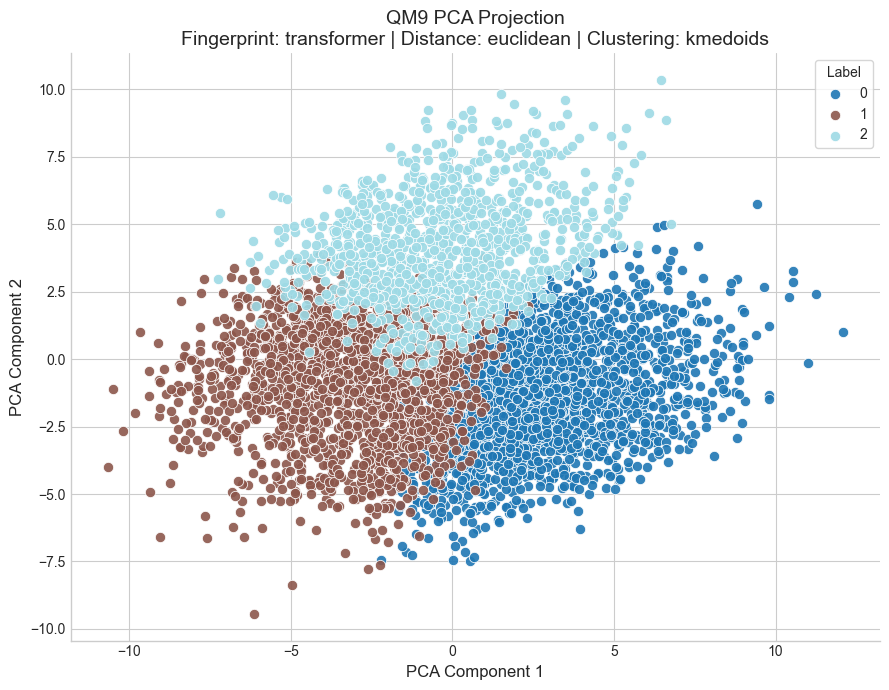

2026-05-08 10:27:08.649 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_kmedoids_projection.png


In [19]:
_=plot_distance_matrix_projection(
    dist_matrix=X,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

In [20]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 72)
┌───────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1429,0.802557,0.0,122.939118,-0.304409,32.26802,0.860704,12.827029,8.838348,2.535339,0.026592,0.002099,2.264521,18.685094,2.146411,1.680196,0.042949,0.121912,0.835139,1.070679,1.6669,7.042687,0.289713,0.745276,5.538838,6.057383,14.769069,1.273165,0.0,0.350595,0.0014,0.130161,0.081875,0.002099,0.021693,0.123863,0.557033,0.0,2.617346,74.795612,-6.459756,0.561455,7.021248,1073.978368,4.067405,-11031.988887,-11031.7746,-11031.748907,-11032.871747,30.386403,-76.129024,-76.609427,-77.04699,-70.823158,3.178563,1.573836,1.276965,0.39888,96.920924,2.309307,0.769769,14.769069,786,"""C1C[NH+]2CC12""",2.029391,250,"""C1CC2CC12""",6.578027,1,null,0.0
1,1562,0.741506,0.0,123.06146,0.266325,30.549296,0.903634,12.82494,8.786172,1.863636,0.119718,0.007042,2.147887,19.145327,2.081465,2.31242,0.038572,0.168595,0.792833,0.768246,1.901408,6.771447,0.259283,1.008963,5.370038,6.335467,13.90781,1.264647,0.0,0.401408,0.025608,0.060179,0.057618,0.0,0.03073,0.085787,0.694622,0.0,2.342327,76.371978,-6.502216,0.705104,7.207354,1168.076105,4.347767,-11071.258306,-11071.026812,-11071.001131,-11072.163299,32.138425,-79.110796,-79.609301,-80.070419,-73.569157,3.263,1.427778,1.156071,0.78041,86.299616,11.267606,2.432778,13.90781,637,"""C1CC1""",4.353393,167,"""C1CC2CC12""",10.56338,1,null,0.0
2,2009,0.750029,0.0,122.259333,0.174714,43.764062,0.819169,12.893503,8.732703,0.89995,0.332006,0.051269,2.825784,17.379791,1.98887,2.686411,0.102892,0.356057,0.541052,0.923345,2.342459,5.915381,0.665505,1.912892,3.328522,6.589348,12.698357,1.253699,0.009457,0.297661,0.05774,0.185167,0.205575,0.002489,0.050274,0.142857,0.376307,0.002489,3.00549,74.49782,-6.578134,-0.186323,6.391816,1286.589606,3.818426,-11344.966686,-11344.724551,-11344.698855,-11345.89886,32.073245,-73.602919,-74.027223,-74.445957,-68.563135,3.792596,1.268312,0.98067,0.858138,44.051767,32.105525,23.842708,12.698357,451,"""Acyclic""",23.842708,91,"""Acyclic""",23.842708,1,null,0.0


# Spectral

In [21]:
kernel = np.exp(-dist_matrix**2 / (2 * np.std(dist_matrix)**2))

model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(kernel)
df = df.with_columns(labels_spectral=labels_spectral)

In [22]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

2026-05-07 20:39:09.070 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 20:39:09.074 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 20:40:02.408 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 20:40:02.412 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 20:40:02.646 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 20:40:02.714 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

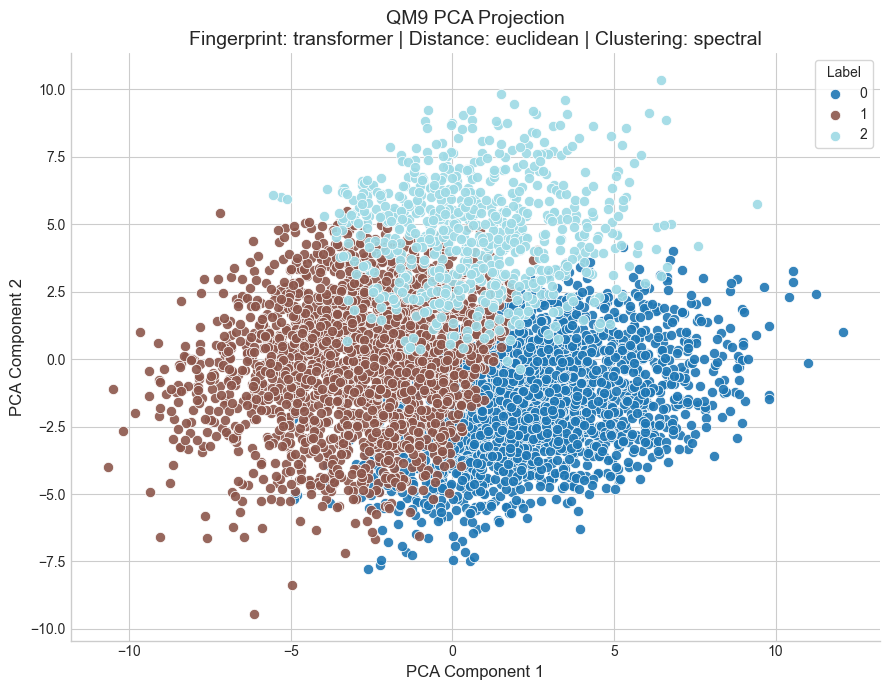

2026-05-07 20:40:03.079 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_spectral_projection.png


{'coords': array([[-2.23530287, -7.61610175],
        [ 1.41616485, -5.95162129],
        [-2.12744132, -1.20228602],
        ...,
        [ 4.06765513, -2.43891753],
        [ 8.97126074, -2.37148786],
        [ 6.95473251, -1.35261645]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'spectral'}

In [23]:
plot_distance_matrix_projection(
    dist_matrix=X,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [24]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_spectral,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2141,0.762119,0.0,122.144792,0.170948,43.360579,0.815299,12.887565,8.738907,1.025222,0.362447,0.04624,2.819243,17.281177,2.002314,2.522186,0.095611,0.362438,0.541951,0.935544,2.376927,6.002335,0.617001,1.953293,3.349369,6.514713,12.844932,1.255703,0.008874,0.285848,0.064456,0.178888,0.200374,0.00327,0.044372,0.137319,0.360579,0.002335,3.017263,74.354661,-6.534614,-0.153375,6.381228,1263.715847,3.799755,-11328.151424,-11327.91266,-11327.886963,-11329.078069,31.780056,-73.424109,-73.84901,-74.265887,-68.399086,3.779463,1.29877,1.00174,0.955628,1.780943,44.558617,34.70341,20.737973,12.844932,563,"""Acyclic""",20.737973,115,"""C1CCCC1""",22.41943,1,null,0.0
1,2128,0.756358,0.0,123.204887,0.211936,29.089286,0.927985,12.797376,8.815789,2.111372,0.030545,0.00188,2.008929,19.256579,2.104544,2.121711,0.037186,0.121476,0.841338,0.795113,1.800282,6.925282,0.258929,0.799342,5.74859,6.217575,14.31203,1.268885,0.0,0.442199,0.007989,0.027256,0.070019,0.0,0.031955,0.117951,0.68515,0.0,2.349036,76.44742,-6.527323,0.78545,7.312818,1143.8723,4.389441,-11037.071986,-11036.843342,-11036.81765,-11037.971683,32.062107,-79.744733,-80.251439,-80.716129,-74.156199,3.122869,1.463979,1.194624,0.677162,0.714756,95.629699,3.007519,1.362782,14.31203,859,"""C1CC1""",3.806391,243,"""C1CC2CC12""",10.009398,1,null,0.0
2,731,0.780667,0.0,122.885089,-0.663475,36.954856,0.775411,12.914276,8.793434,2.262654,0.069767,0.019152,2.677155,18.529412,2.118586,2.045144,0.060873,0.161963,0.777163,1.21751,1.556772,6.753762,0.388509,0.822161,4.905609,6.307798,14.20383,1.265071,0.0,0.236662,0.004104,0.288646,0.057456,0.001368,0.023256,0.072503,0.556772,0.0,2.706188,73.828509,-6.459879,0.254868,6.714806,1100.181392,3.828651,-11093.836229,-11093.62212,-11093.596453,-11094.724655,29.806125,-72.95471,-73.405607,-73.823369,-67.876637,3.448703,1.547504,1.250134,0.035568,0.336525,86.046512,6.429549,7.52394,14.20383,397,"""Acyclic""",7.52394,145,"""C1CCCC1""",8.618331,1,null,0.0


# DBSCAN 

In [25]:
model_db = DBSCAN(
    eps=2,
    min_samples=3,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db,return_counts=True))

(array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
        12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
        38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
        51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
       103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
       116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139]), array([2630,    4, 1492,    4,  272,    4,   12,   11,   12,    6,    4,
          3,    8,    7,    3,    3,    3,   11,    5,    4,    8,    5,
          4,   15,    5,    7,    3,    6,    4,    4,    3,    3,   

In [26]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-05-07 20:40:03.359 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 20:40:03.359 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 20:40:58.518 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 20:40:58.524 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 20:40:58.778 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 20:40:58.851 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

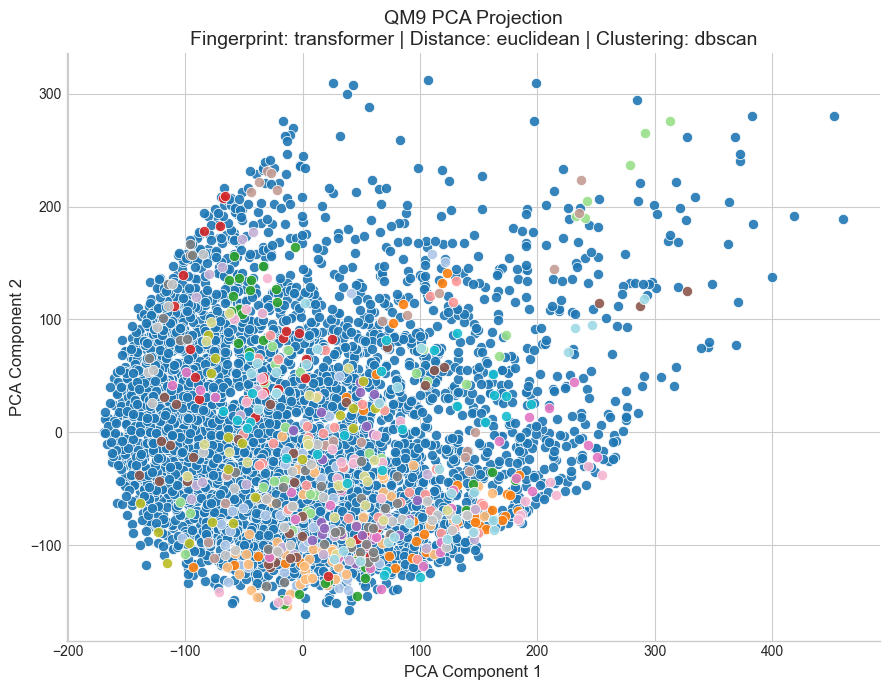

2026-05-07 20:41:00.062 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_dbscan_projection.png


{'coords': array([[  67.31170509,   96.40823116],
        [ 244.1663337 ,  184.09230328],
        [ -65.47699724,   10.17606785],
        ...,
        [  64.97582183, -117.92291007],
        [ 264.55359422,  -23.76574645],
        [ 177.61404392,  -71.09163635]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'dbscan'}

In [27]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

In [28]:
average_numeric_by_cluster(df, "labels_db")

shape: (141, 74)
┌───────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬─────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,2630,0.751581,0.0,122.211407,0.057034,38.34981,0.833369,12.872824,8.739924,1.446008,0.186692,0.026236,2.551711,18.144867,2.042845,2.385551,0.080121,0.244521,0.675358,0.928517,2.04981,6.337643,0.518631,1.338783,4.330798,6.428897,13.308745,1.259849,0.004563,0.31673,0.027376,0.148669,0.139544,0.001521,0.0327,0.114449,0.477947,0.001901,2.7709,74.980909,-6.569041,0.18026,6.749279,1216.371657,3.994064,-11144.394569,-11144.160994,-11144.135302,-11145.310388,31.650983,-75.190337,-75.643409,-76.075612,-69.984849,3.618638,1.365945,1.089324,0.652091,1.213688,0.686692,68.060837,17.604563,14.334601,13.308745,925,"""Acyclic""",14.334601,223,"""Acyclic""",14.334601,1,null,0.0
0,4,0.771384,0.0,107.25,-0.25,44.5,0.814398,12.976696,7.5,0.0,0.0,0.0,3.25,14.25,1.856086,2.25,0.125,0.475,0.4,0.75,2.0,5.0,0.5,2.0,1.75,6.0,11.0,1.236872,0.0,0.0,0.0,0.0,1.5,0.0,0.0,0.0,0.0,0.0,3.10835,60.559999,-6.891283,-1.619758,5.272206,985.551132,3.039376,-10471.074341,-10470.844482,-10470.819092,-10471.988647,28.17625,-60.417073,-60.736309,-61.076847,-56.366801,5.224013,1.768293,1.31411,0.0,2.0,0.0,0.0,0.0,100.0,11.0,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0
1,1492,0.778974,0.0,123.654826,0.065013,29.103887,0.93537,12.792319,8.849866,2.280831,0.002681,0.006032,2.050268,19.113941,2.118029,1.99866,0.037035,0.115996,0.84697,0.845845,1.757373,6.955094,0.254692,0.774129,5.770777,6.121314,14.662869,1.270843,0.0,0.463807,0.0,0.040885,0.08378,0.00134,0.043566,0.14008,0.689678,0.0,2.417991,75.807487,-6.515278,0.679955,7.195331,1113.440283,4.311927,-11123.614008,-11123.389713,-11123.364036,-11124.507218,31.673074,-79.087462,-79.589438,-80.048069,-73.556735,3.046417,1.510379,1.230663,0.661528,0.688338,1.008713,95.77748,0.268097,3.954424,14.662869,710,"""Acyclic""",3.954424,225,"""C1CC2CC12""",9.24933,1,null,0.0
2,4,0.751394,0.0,118.25,-1.0,20.5,0.805898,12.88313,8.5,2.75,0.0,0.0,2.0,19.25,2.179991,1.25,0.0,0.071429,0.928571,1.5,1.0,7.75,0.0,0.5,6.0,6.0,14.5,1.269824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,1.834975,73.229999,-6.136168,0.19184,6.327328,1007.393356,4.044462,-10282.687988,-10282.48999,-10282.464355,-10283.550293,28.53625,-74.069942,-74.556252,-74.986772,-68.861489,4.489043,1.594282,1.381353,0.0,0.25,1.5,100.0,0.0,0.0,14.5,4,"""C1C[NH+]2CC12""",25.0,4,"""CC1CC2C3CCC1C32""",25.0,1,null,0.0
3,272,0.799388,0.0,122.033088,0.191176,50.341912,0.698304,12.966886,8.764706,1.150735,0.9375,0.069853,3.430147,15.977941,2.019616,2.330882,0.033675,0.637443,0.328882,1.1875,2.911765,6.143382,0.198529,3.345588,1.790441,6.477941,12.584559,1.255074,0.011029,0.121324,0.224265,0.327206,0.080882,0.0,0.014706,0.051471,0.231618,0.0,2.989243,72.63136,-6.036256,-0.127683,5.908652,1178.282162,3.436072,-11520.2343,-11520.010577,-11519.984917,-11521.14093,29.931279,-69.380639,-69.772688,-70.157626,-64.684459,3.835152,1.

# HDBSCAN

In [29]:
from src.helper_functions import evaluate_hdbscan_grid
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=10, ms=1, clusters=4, noise=0.24, persistence=0.032, score=0.024
mcs=10, ms=1, clusters=4, noise=0.24, persistence=0.032, score=0.024
mcs=10, ms=2, clusters=2, noise=0.33, persistence=0.025, score=0.017


In [30]:
from hdbscan import HDBSCAN
clusterer = HDBSCAN(
        min_cluster_size=10,
        min_samples=1,
        metric='precomputed',
    )

labels_hdbscan = clusterer.fit_predict(dist_matrix.astype(np.float64))
df = df.with_columns(labels_hdbscan=labels_hdbscan)

In [31]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

2026-05-07 20:41:39.750 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 20:41:39.751 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 20:42:36.615 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 20:42:36.619 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 20:42:36.885 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 20:42:37.500 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

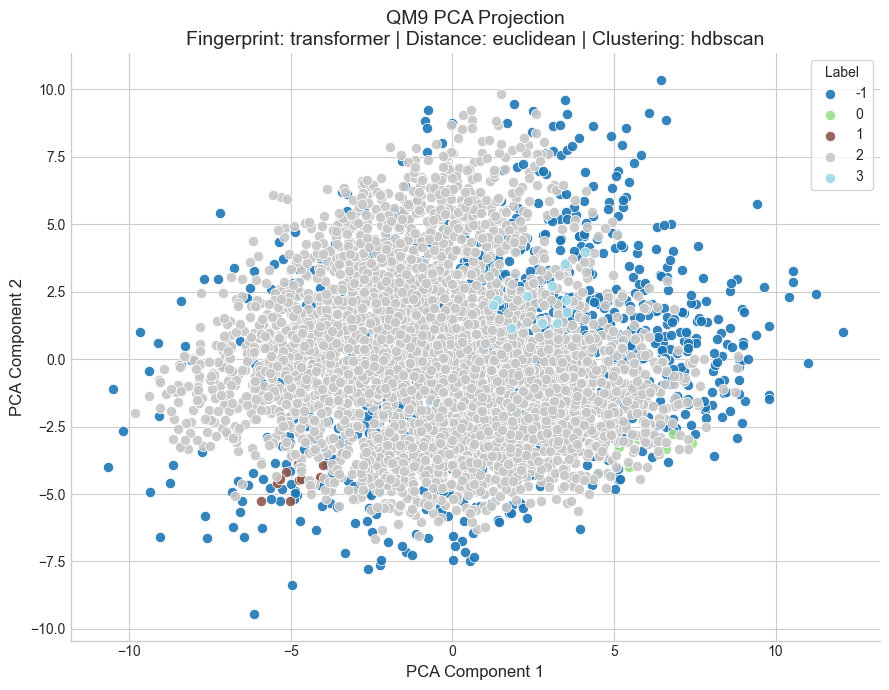

2026-05-07 20:42:38.533 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_hdbscan_projection.png


In [32]:
_=plot_distance_matrix_projection(
    dist_matrix=X,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

In [33]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (5, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,1188,0.735161,0.0,121.26431,0.0867,37.963805,0.812041,12.879885,8.690236,1.271886,0.185185,0.034512,2.522727,18.051347,2.024701,2.479798,0.110412,0.239967,0.649621,0.872896,1.973064,6.151515,0.717172,1.274411,4.175926,6.561448,12.882155,1.257101,0.005051,0.248316,0.021044,0.155724,0.131313,0.001684,0.017677,0.117003,0.424242,0.001684,2.818037,75.370051,-6.631314,0.109796,6.741067,1265.999433,3.952528,-11007.507891,-11007.271087,-11007.245372,-11008.431261,31.741165,-74.633731,-75.078241,-75.506908,-69.481035,3.944253,1.323328,1.056846,0.632155,1.281145,0.669192,2.277778,62.037037,16.919192,21.043771,12.882155,474,"""Acyclic""",21.043771,138,"""Acyclic""",21.043771,1,null,0.0
0,12,0.674532,0.0,125.583333,-0.083333,44.75,0.952289,12.806188,8.916667,0.0,0.0,0.0,2.75,17.666667,1.885112,3.75,0.264683,0.203968,0.531349,0.75,2.5,4.916667,1.666667,1.25,3.25,7.916667,11.75,1.241335,0.0,0.5,0.0,0.166667,0.25,0.0,0.333333,0.333333,0.416667,0.0,2.971808,75.925833,-6.900127,-0.465995,6.434359,1781.73586,3.830896,-11837.21875,-11836.932048,-11836.906494,-11838.242269,35.458584,-75.197153,-75.591593,-76.019952,-70.123192,4.594988,0.738724,0.652789,0.0,2.0,0.0,-1.0,0.0,0.0,100.0,11.75,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0
1,11,0.582545,0.0,124.363636,1.0,17.0,0.929137,12.835682,8.818182,1.090909,0.0,0.0,1.272727,22.818182,2.009569,4.272727,0.063131,0.015152,0.921717,0.454545,1.090909,7.272727,0.545455,0.090909,6.909091,7.363636,13.181818,1.245969,0.0,0.181818,0.0,0.090909,0.090909,0.0,0.0,0.0,0.727273,0.0,1.548691,84.763637,-6.680148,1.802878,8.482778,1494.645724,5.496158,-10499.159979,-10498.88157,-10498.855824,-10500.131037,37.581637,-91.334921,-91.932254,-92.490752,-84.768649,3.109383,1.064103,0.880631,0.545455,1.0,1.0,41.0,100.0,0.0,0.0,13.181818,8,"""C1CC1""",18.181818,4,"""C1CC1""",54.545455,1,null,0.0
2,3778,0.771616,0.0,123.140815,0.058761,35.825304,0.871564,12.844571,8.807041,1.802276,0.177343,0.020116,2.431975,18.376125,2.075743,2.208841,0.050981,0.227601,0.721417,0.932239,2.025675,6.61964,0.337215,1.303864,4.733986,6.285601,13.922975,1.264583,0.003441,0.376125,0.035204,0.122022,0.120434,0.001588,0.041027,0.119905,0.560614,0.000794,2.645938,75.070866,-6.484641,0.369799,6.854482,1161.716337,4.085186,-11219.967089,-11219.738421,-11219.712738,-11220.871804,31.543447,-76.462307,-76.931814,-77.371701,-71.153776,3.293771,1.434479,1.142648,0.728957,1.059026,0.733722,9.232398,75.754367,17.231339,7.014293,13.922975,1279,"""Acyclic""",7.014293,285,"""C1CCCC1""",13.234516,1,null,0.0
3,11,0.805014,0.0,123.454545,-0.272727,52.545455,0.728366,12.951704,8.818182,0.909091,0.181818,0.0,3.272727,17.181818,1.989305,2.454545,0.062338,0.482035,0.455628,1.090909,1.727273,6.272727,0.363636,2.545455,2.636364,6.545455,13.545455,1.252822,0.0,0.181818,0.0,0.272727,0

# KMeans on Raw Embeddings


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X_raw = np.array(df["selfies_transformer"].to_list(), dtype=np.float32)
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_raw)

kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans_raw = kmeans_raw.fit_predict(X_pca)
df = df.with_columns(labels_kmeans_raw=labels_kmeans_raw)


In [ ]:
average_numeric_by_cluster(df, "labels_kmeans_raw")

shape: (3, 76)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_kmeans_raw,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2039,0.760705,0.0,122.557626,0.170672,41.952918,0.843997,12.871329,8.760177,1.102992,0.28102,0.045611,2.703776,17.580186,2.009363,2.530162,0.091262,0.319785,0.588953,0.922511,2.297695,6.099068,0.596861,1.76459,3.694949,6.471309,13.07847,1.257198,0.009318,0.323198,0.050025,0.156449,0.209416,0.002943,0.049534,0.158901,…,2.981734,74.663556,-6.577558,-0.082291,6.495254,1263.187204,3.891553,-11333.505577,-11333.265124,-11333.239421,-11334.433402,32.111165,-74.531707,-74.966925,-75.391816,-69.416918,3.653874,1.296536,1.010025,1.699362,1.897989,0.100049,11.171162,1.195194,52.378617,27.219225,20.402158,13.07847,556,"""Acyclic""",20.402158,140,"""Acyclic""",20.402158,1,null,0.0
1,1081,0.79015,0.0,122.650324,-0.565217,36.358002,0.789463,12.89345,8.792784,2.309898,0.075856,0.012951,2.607771,18.414431,2.123853,1.905643,0.058937,0.162117,0.778947,1.192414,1.633673,6.783534,0.382054,0.845513,4.957447,6.242368,14.283071,1.267296,0.0,0.271045,0.004625,0.233117,0.070305,0.00185,0.020352,0.085106,…,2.713539,73.958409,-6.441509,0.328717,6.770263,1091.039034,3.86387,-11071.752856,-11071.539285,-11071.513603,-11072.638901,29.873051,-73.418113,-73.873543,-74.293968,-68.30867,3.400772,1.556375,1.254697,1.827012,1.076781,1.606846,5.387604,1.122109,87.789084,6.93802,5.272895,14.283071,588,"""Acyclic""",5.272895,193,"""C1CCCC1""",7.493062,1,null,0.0
2,1880,0.748226,0.0,122.894149,0.316489,30.269149,0.911071,12.81009,8.793085,1.912766,0.126064,0.005319,2.093617,19.026596,2.085709,2.229255,0.041776,0.173184,0.78504,0.75266,1.918617,6.785106,0.279787,1.048936,5.370745,6.301596,13.953723,1.265979,0.0,0.411702,0.027128,0.043085,0.062234,0.0,0.030319,0.096809,…,2.353106,76.411729,-6.504262,0.713733,7.218049,1164.338605,4.342038,-11049.187743,-11048.957367,-11048.931686,-11050.091091,32.069205,-79.198176,-79.697037,-80.157648,-73.660579,3.261603,1.436788,1.162215,0.471277,0.338298,0.877128,5.105319,1.470745,85.159574,11.914894,2.925532,13.953723,742,"""C1CC1""",4.042553,194,"""C1CC2CC12""",9.521277,1,null,0.0


In [ ]:

create_chemiscope_viewer(df, X_raw, labels_kmeans_raw, 'PCA')

2026-05-07 08:41:49.554 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...


2026-05-07 08:41:49.696 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:43:52.406 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:43:52.436 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:43:52.974 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json


JSONDecodeError: Extra data: line 471168 column 7 (char 10698195)